In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
import warnings
warnings.filterwarnings('ignore')

In [96]:
df = pd.read_csv("C:/Users/sahil/Downloads/german_credit_data (1).csv")

In [97]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [98]:
df = df.drop('Unnamed: 0', axis = 1)

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [101]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


## Dealing with nulls

In [103]:
df['Saving accounts'].unique()

<StringArray>
[nan, 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

In [104]:
df['Saving accounts'].mode()[0]

'little'

In [105]:
df['Saving accounts'] = df['Saving accounts'].fillna(df['Saving accounts'].mode()[0])

In [106]:
df['Checking account'].unique()

<StringArray>
['little', 'moderate', nan, 'rich']
Length: 4, dtype: str

In [107]:
df['Checking account'].mode()[0]

'little'

In [108]:
df['Checking account'] = df['Checking account'].fillna(df['Checking account'].mode()[0])

In [109]:
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

## EDA

In [111]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,little,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,little,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


<Axes: xlabel='Sex'>

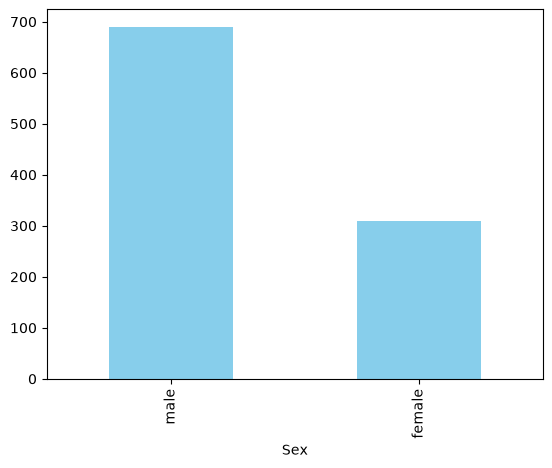

In [112]:
df['Sex'].value_counts().plot(kind = 'bar', color = 'skyblue')

In [ ]:
sns.countplot(data=df, x='Housing', hue='Risk')
plt.title('Housing Type by Credit Risk')
plt.xlabel('Housing')
plt.ylabel('Count')
plt.show()

ValueError: The following variable cannot be assigned with wide-form data: `hue`

<Axes: xlabel='Age', ylabel='Count'>

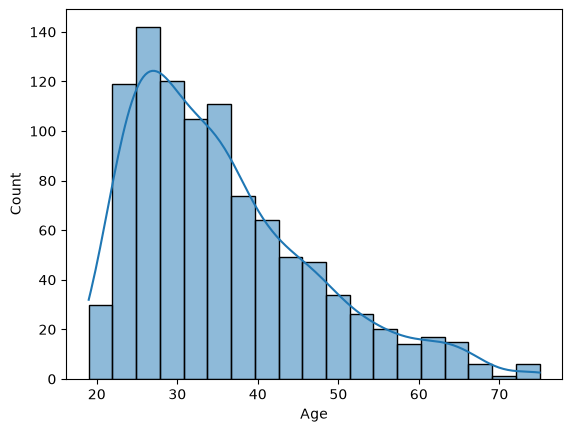

In [66]:
sns.histplot(data=df['Age'], kde=True)

In [67]:
df['Job'].unique()

array([2, 1, 3, 0])

<Axes: xlabel='Purpose'>

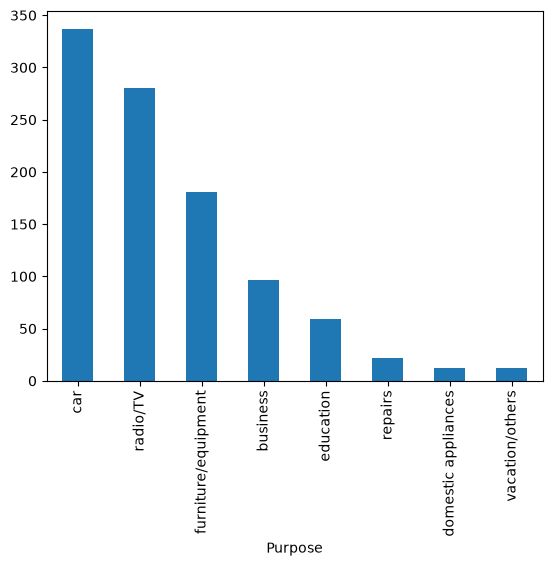

In [68]:
df['Purpose'].value_counts().plot(kind = 'bar')

<Axes: xlabel='Age', ylabel='Risk'>

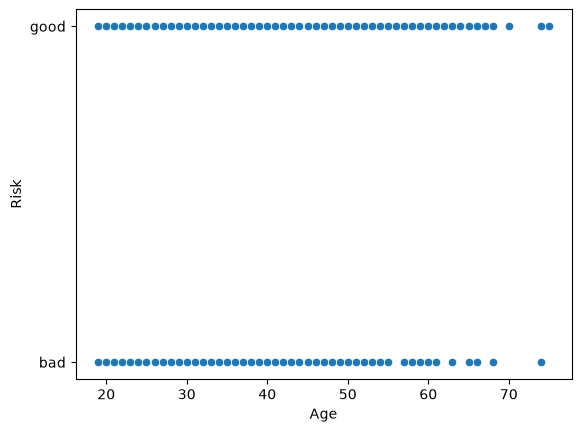

In [69]:
sns.scatterplot(data=df, x='Age', y='Risk')

<Axes: xlabel='Age', ylabel='Density'>

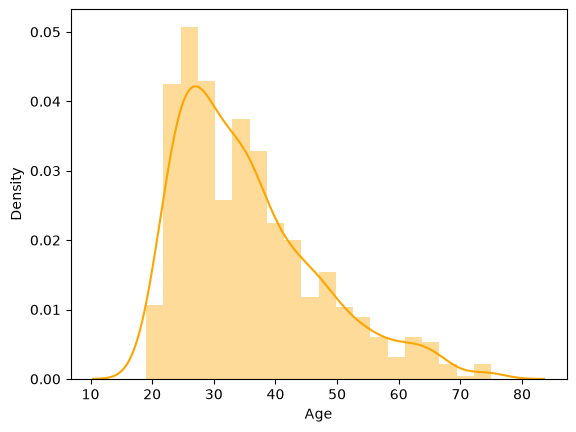

In [70]:
sns.distplot(df['Age'], bins =  20, color= 'orange')

## Treating Unbalance

In [71]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [72]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [73]:
X = df.drop('Risk', axis=1)
X.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,little,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,little,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [74]:
y = df['Risk']
y

0      good
1       bad
2      good
3      good
4       bad
       ... 
995    good
996    good
997    good
998     bad
999    good
Name: Risk, Length: 1000, dtype: str

In [75]:
y = df['Risk'].map({'good': 0, 'bad': 1})  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [76]:
encoder = LabelEncoder()
X_train['Sex'] = encoder.fit_transform(X_train['Sex'])
X_test['Sex'] = encoder.transform(X_test['Sex'])

In [77]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [78]:
cols = ['Housing', 'Saving accounts', 'Checking account', 'Purpose']

In [79]:
preporcessor = ColumnTransformer([
        ('OneHotEncoder',OneHotEncoder(drop= 'first'), cols)
])

In [80]:
X_train = preporcessor.fit_transform(X_train)
X_test = preporcessor.transform(X_test)

In [81]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1881 stored elements and shape (800, 14)>

In [82]:
X_train_dense = X_train.toarray()
X_train_dense

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(800, 14))

In [83]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_dense, y_train)

In [84]:
print(pd.Series(y_train_res).value_counts())

Risk
1    560
0    560
Name: count, dtype: int64


In [85]:
y_train_res

0       1
1       0
2       0
3       0
4       0
       ..
1115    1
1116    1
1117    1
1118    1
1119    1
Name: Risk, Length: 1120, dtype: int64

In [86]:
X_test_dense = X_test.toarray()

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix, recall_score, roc_auc_score

In [88]:
def evaluate_model(true, predicted):
    cr = classification_report(true, predicted)
    f1 = f1_score(true, predicted)
    accuracy = accuracy_score(true, predicted)
    conf_mat = confusion_matrix(true, predicted)
    recall = recall_score(true, predicted)
    return cr, f1, accuracy, conf_mat, recall

In [89]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest Classifier": RandomForestClassifier(),
    "Adaboost Classifier":AdaBoostClassifier()
   
}

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

needs_scaling = ['Logistic Regression', 'KNN']

for name, model in models.items():

    # Scale only for LR and KNN
    if name in needs_scaling:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_train_res)
        X_te = scaler.transform(X_test_dense)
    else:
        X_tr = X_train_res
        X_te = X_test_dense

    # Train
    model.fit(X_tr, y_train_res)

    # Predict
    y_train_pred = model.predict(X_tr)
    y_test_pred  = model.predict(X_te)

    # Evaluate
    model_train_cr, model_train_f1, model_train_accuracy, model_train_conf, model_train_recall = evaluate_model(y_train_res, y_train_pred)
    model_test_cr,  model_test_f1,  model_test_accuracy,  model_test_conf,  model_test_recall  = evaluate_model(y_test, y_test_pred)

    # AUC
    y_test_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, y_test_prob)

    # Print results
    print(name)
    print('Model performance for Training set')
    print("- Classification Report:\n", model_train_cr)
    print("- F1 Score:    {:.4f}".format(model_train_f1))
    print("- Accuracy:    {:.4f}".format(model_train_accuracy))
    print("- Recall:      {:.4f}".format(model_train_recall))
    print("- Confusion Matrix:\n", model_train_conf)
    print('----------------------------------')
    print('Model performance for Test set')
    print("- Classification Report:\n", model_test_cr)
    print("- F1 Score:    {:.4f}".format(model_test_f1))
    print("- Accuracy:    {:.4f}".format(model_test_accuracy))
    print("- Recall:      {:.4f}".format(model_test_recall))
    print("- AUC Score:   {:.4f}".format(auc))
    print("- Confusion Matrix:\n", model_test_conf)
    print('='*35)
    print('\n')

Logistic Regression
Model performance for Training set
- Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.70      0.65       560
           1       0.65      0.55      0.59       560

    accuracy                           0.62      1120
   macro avg       0.63      0.62      0.62      1120
weighted avg       0.63      0.62      0.62      1120

- F1 Score:    0.5924
- Accuracy:    0.6241
- Recall:      0.5464
- Confusion Matrix:
 [[393 167]
 [254 306]]
----------------------------------
Model performance for Test set
- Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.68      0.71       140
           1       0.37      0.43      0.40        60

    accuracy                           0.60       200
   macro avg       0.55      0.56      0.55       200
weighted avg       0.63      0.60      0.61       200

- F1 Score:    0.3969
- Accuracy:    0.6050
- Recall:      0.43

In [90]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':   [50, 100, 200],
    'learning_rate':  [0.01, 0.1, 0.5, 1.0]
}

grid = GridSearchCV(AdaBoostClassifier(), params, 
                    cv=5, scoring='roc_auc', verbose=1)
grid.fit(X_train_res, y_train_res)

print("Best params:", grid.best_params_)
print("Best AUC:   ", grid.best_score_.round(4))

# Evaluate best model
best_model = grid.best_estimator_
y_test_pred = best_model.predict(X_test_dense)
y_test_prob = best_model.predict_proba(X_test_dense)[:, 1]

print(classification_report(y_test, y_test_pred, target_names=['good', 'bad']))
print("Test AUC:", roc_auc_score(y_test, y_test_prob))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'learning_rate': 1.0, 'n_estimators': 200}
Best AUC:    0.6672
              precision    recall  f1-score   support

        good       0.74      0.68      0.71       140
         bad       0.37      0.43      0.40        60

    accuracy                           0.60       200
   macro avg       0.55      0.56      0.55       200
weighted avg       0.63      0.60      0.61       200

Test AUC: 0.5773809523809523


In [91]:

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# Class weight to handle imbalance (bad:good ratio in original data)
scale = (y_train_res == 0).sum() / (y_train_res == 1).sum()

params = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.01, 0.1, 0.2],
    'scale_pos_weight':[scale]           # handles class imbalance
}

xgb = XGBClassifier(eval_metric='auc', random_state=42)

grid = GridSearchCV(xgb, params, cv=5, scoring='roc_auc', verbose=1)
grid.fit(X_train_res, y_train_res)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_.round(4))

# Evaluate
best_xgb    = grid.best_estimator_
y_test_pred = best_xgb.predict(X_test_dense)
y_test_prob = best_xgb.predict_proba(X_test_dense)[:, 1]

print(classification_report(y_test, y_test_pred, target_names=['good', 'bad']))
print("Test AUC:", round(roc_auc_score(y_test, y_test_prob), 4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': np.float64(1.0)}
Best CV AUC: 0.6933
              precision    recall  f1-score   support

        good       0.73      0.64      0.68       140
         bad       0.35      0.45      0.39        60

    accuracy                           0.58       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.61      0.58      0.59       200

Test AUC: 0.5861
